In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
df = pd.read_csv('loan_approval_data.csv')
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [17]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

## Handle Missing Values


In [15]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns
categorical_cols, numerical_cols

(Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
        'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
       dtype='str'),
 Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
        'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
        'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
       dtype='str'))

In [23]:
from sklearn.impute import SimpleImputer

# Impute numerical columns with mean
num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# Impute categorical columns with most_frequent
cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## EDA - Exploratory Data Analysis


Text(0.5, 1.0, 'Is loan Approved or not?')

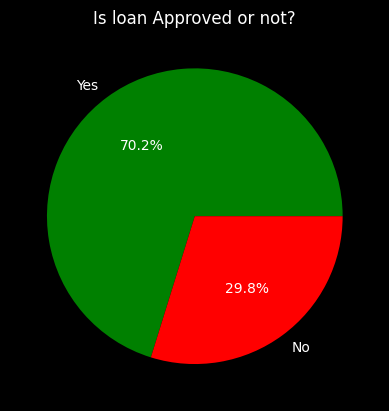

In [28]:
import matplotlib.pyplot as plt

#how balanced our classes are

classes_count = df["Loan_Approved"].value_counts()
plt.pie(
    classes_count,
    labels=["Yes", "No"],
    autopct="%1.1f%%",
    colors=["green", "red"]
)
plt.title("Is loan Approved or not?")

[Text(0, 2, '621'), Text(0, 2, '379')]

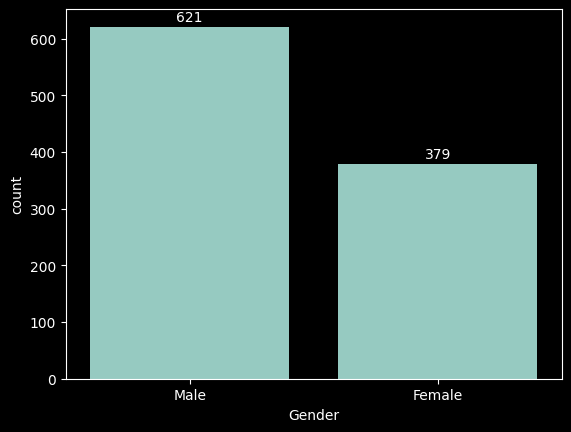

In [40]:
import seaborn as sns

gender_cnt = df["Gender"].value_counts()

ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0], padding=2)

### Check outlier


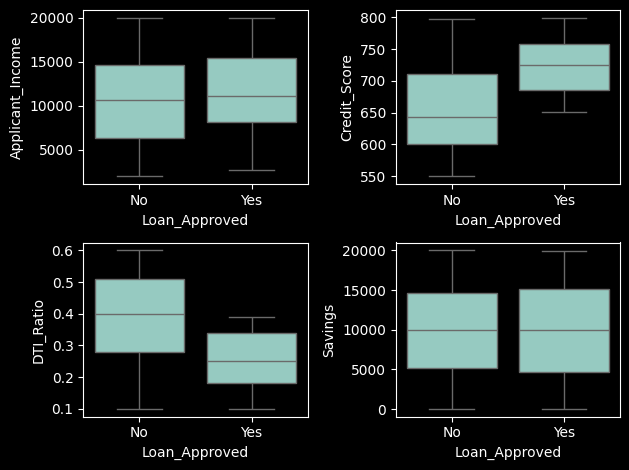

In [46]:
fig, axes = plt.subplots(2,2)
sns.boxplot(ax=axes[0,0], data=df, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[1,0], data=df, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data=df, x="Loan_Approved", y="Savings")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

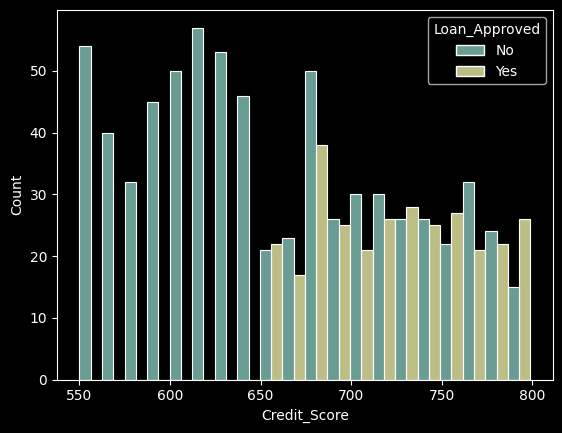

In [53]:
sns.histplot(
    data=df,
    x="Credit_Score",
    bins= 20,
    hue="Loan_Approved",
    multiple="dodge"
    )

### remove unnecessery cols


In [ ]:
df = df.drop(["Applicant_ID"], axis=1)
df.head()

### Encoding

- LabelEncoder(Ordinal) - Assign an integer to each category.
- OneHotEncoder(Nominal) - Creates Binary Columns for each Category.


In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

